# DQN vs Dueling DQN — comparación visual en Gymnasium

Este notebook entrena **dos agentes** sobre el mismo entorno de [Gymnasium](https://gymnasium.farama.org/) — uno con un **DQN estándar** y otro con **Dueling DQN** — y compara su desempeño con:

1. Un **gráfico de matplotlib** con las curvas de aprendizaje (retorno por episodio) de ambos agentes superpuestas.
2. **GIFs animados** de cada agente ya entrenado jugando un episodio.



Entorno usado: **`LunarLander-v3`** (4 acciones discretas).

In [ ]:
!pip install -q swig
!pip install -q "gymnasium[box2d]" imageio imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 117.6 MB/s eta 0:00:00


In [ ]:
import random
from collections import deque, namedtuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image, display

SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: cuda


## Arquitecturas de red

- **DQN estándar:** el tronco de capas termina directamente en una capa que produce $Q(s,a)$ para cada acción.
- **Dueling DQN:** el tronco se bifurca en dos cabezas: una estima el **valor de estado** $V(s)$ (un solo número) y otra la **ventaja** $A(s,a)$ (un valor por acción). Se combinan como:

$$Q(s,a) = V(s) + \left(A(s,a) - \frac{1}{|\mathcal{A}|}\sum_{a'} A(s,a')\right)$$

Restar el promedio de las ventajas es lo que da identificabilidad al modelo (si no, $V$ y $A$ podrían compensarse de infinitas formas). La idea es que $V(s)$ puede aprender "qué tan bueno es este estado" incluso en pasos donde la acción elegida no importa mucho, mientras que $A(s,a)$ se especializa en las diferencias relevantes entre acciones.

In [ ]:
class QNetwork(nn.Module):
    """DQN estándar: una sola cabeza que produce directamente Q(s,a)."""
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class DuelingQNetwork(nn.Module):
    """Dueling DQN: tronco compartido -> dos cabezas (V(s) y A(s,a)) combinadas."""
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.trunk = nn.Sequential(nn.Linear(obs_dim, hidden), nn.ReLU())
        self.value_head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )
        self.adv_head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        z = self.trunk(x)
        v = self.value_head(z)                 # (B, 1)
        a = self.adv_head(z)                    # (B, n_actions)
        q = v + (a - a.mean(dim=1, keepdim=True))
        return q

    def value_advantage(self, x):
        """Devuelve V(s) y A(s,a) por separado, útil solo para visualizar/depurar."""
        z = self.trunk(x)
        v = self.value_head(z)
        a = self.adv_head(z)
        return v, a

In [ ]:
Transition = namedtuple("Transition", ["obs", "action", "reward", "next_obs", "done"])


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        obs, action, reward, next_obs, done = map(np.array, zip(*batch))
        return obs, action, reward, next_obs, done

    def __len__(self):
        return len(self.buffer)

## Bucle de entrenamiento

Una sola función de entrenamiento, parametrizada por la **clase de red** (`QNetwork` o `DuelingQNetwork`). Todo lo demás —hiperparámetros, semilla, entorno, epsilon-greedy, target network— es idéntico entre ambos agentes, para que la comparación sea justa.

In [ ]:
def train_dqn(env_id, network_cls, total_timesteps=150_000, seed=SEED,
              buffer_size=50_000, batch_size=128, gamma=0.99,
              lr=1e-3, target_update_freq=500,
              start_eps=1.0, end_eps=0.05, eps_decay_frac=0.4,
              learning_starts=2_000, train_freq=4, log_every=10_000):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

    env = gym.make(env_id)
    obs, _ = env.reset(seed=seed)
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    q_net = network_cls(obs_dim, n_actions).to(device)
    target_net = network_cls(obs_dim, n_actions).to(device)
    target_net.load_state_dict(q_net.state_dict())
    optimizer = torch.optim.Adam(q_net.parameters(), lr=lr)
    buffer = ReplayBuffer(buffer_size)

    episode_returns = []
    log_returns = []  # (timestep, retorno) para graficar
    ep_return = 0.0

    for step in range(1, total_timesteps + 1):
        eps = np.interp(step, [0, eps_decay_frac * total_timesteps], [start_eps, end_eps])
        if random.random() < eps:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
                action = int(q_net(obs_t).argmax(dim=1).item())

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer.push(obs, action, reward, next_obs, float(done))
        obs = next_obs
        ep_return += reward

        if done:
            episode_returns.append(ep_return)
            log_returns.append((step, ep_return))
            obs, _ = env.reset()
            ep_return = 0.0

        if len(buffer) > learning_starts and step % train_freq == 0:
            b_obs, b_act, b_rew, b_next_obs, b_done = buffer.sample(batch_size)
            b_obs = torch.tensor(b_obs, dtype=torch.float32, device=device)
            b_act = torch.tensor(b_act, dtype=torch.int64, device=device)
            b_rew = torch.tensor(b_rew, dtype=torch.float32, device=device)
            b_next_obs = torch.tensor(b_next_obs, dtype=torch.float32, device=device)
            b_done = torch.tensor(b_done, dtype=torch.float32, device=device)

            with torch.no_grad():
                next_q = target_net(b_next_obs).max(dim=1)[0]
                target = b_rew + gamma * (1 - b_done) * next_q
            current_q = q_net(b_obs).gather(1, b_act.unsqueeze(1)).squeeze(1)
            loss = F.smooth_l1_loss(current_q, target)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(q_net.parameters(), 10.0)
            optimizer.step()

        if step % target_update_freq == 0:
            target_net.load_state_dict(q_net.state_dict())

        if step % log_every == 0 and episode_returns:
            recent = episode_returns[-10:]
            print(f"[{network_cls.__name__:16s}] step={step:>7} eps={eps:.2f} "
                  f"retorno_medio(10 ep)={np.mean(recent):7.1f}")

    env.close()
    return q_net, log_returns

## Entrenar ambos agentes

`TOTAL_STEPS` está en un valor que entrena en pocos minutos en Colab (CPU). Subir (p. ej. a `300_000`) para ver a los agentes resolver mejor el entorno (LunarLander se considera "resuelto" con retorno medio ≥ 200).

In [ ]:
ENV_ID = "LunarLander-v3"
TOTAL_STEPS = 150_000

print("=== Entrenando DQN estándar ===")
dqn_net, dqn_log = train_dqn(ENV_ID, QNetwork, total_timesteps=TOTAL_STEPS)

print("\n=== Entrenando Dueling DQN ===")
dueling_net, dueling_log = train_dqn(ENV_ID, DuelingQNetwork, total_timesteps=TOTAL_STEPS)

=== Entrenando DQN estándar ===
[QNetwork        ] step=  10000 eps=0.84 retorno_medio(10 ep)= -113.9
[QNetwork        ] step=  20000 eps=0.68 retorno_medio(10 ep)=  -49.4
[QNetwork        ] step=  30000 eps=0.53 retorno_medio(10 ep)=  -37.2
[QNetwork        ] step=  40000 eps=0.37 retorno_medio(10 ep)=   -7.5
[QNetwork        ] step=  50000 eps=0.21 retorno_medio(10 ep)=   -0.3
[QNetwork        ] step=  60000 eps=0.05 retorno_medio(10 ep)=  -23.1
[QNetwork        ] step=  70000 eps=0.05 retorno_medio(10 ep)=  -36.7
[QNetwork        ] step=  80000 eps=0.05 retorno_medio(10 ep)=  140.3
[QNetwork        ] step=  90000 eps=0.05 retorno_medio(10 ep)=   -6.5
[QNetwork        ] step= 100000 eps=0.05 retorno_medio(10 ep)=  -24.0
[QNetwork        ] step= 110000 eps=0.05 retorno_medio(10 ep)=  -30.0
[QNetwork        ] step= 120000 eps=0.05 retorno_medio(10 ep)=    6.0
[QNetwork        ] step= 130000 eps=0.05 retorno_medio(10 ep)=  -19.9
[QNetwork        ] step= 140000 eps=0.05 retorno_medio(10 

## Gráfico 1 — curvas de aprendizaje comparadas

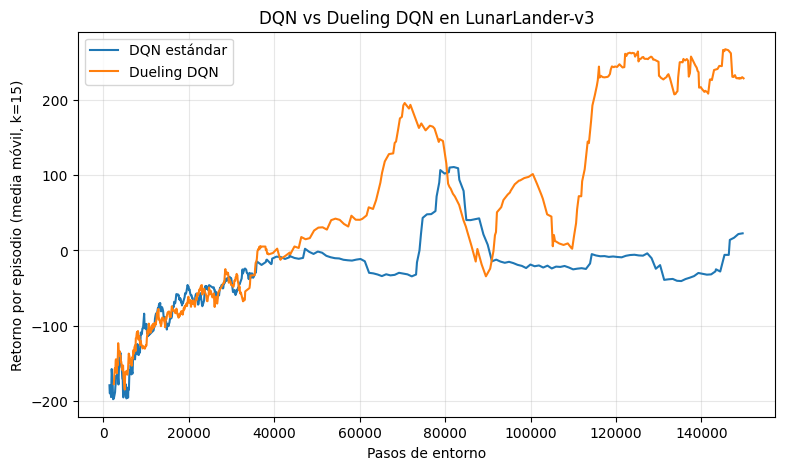

In [ ]:
def smooth(xs, ys, k=15):
    ys = np.array(ys, dtype=float)
    if len(ys) < k:
        return xs, ys
    kernel = np.ones(k) / k
    ys_smooth = np.convolve(ys, kernel, mode="valid")
    xs_smooth = xs[k - 1:]
    return xs_smooth, ys_smooth

dqn_x = [s for s, _ in dqn_log]
dqn_y = [r for _, r in dqn_log]
duel_x = [s for s, _ in dueling_log]
duel_y = [r for _, r in dueling_log]

dqn_xs, dqn_ys = smooth(dqn_x, dqn_y)
duel_xs, duel_ys = smooth(duel_x, duel_y)

plt.figure(figsize=(9, 5))
plt.plot(dqn_xs, dqn_ys, label="DQN estándar", color="tab:blue")
plt.plot(duel_xs, duel_ys, label="Dueling DQN", color="tab:orange")
plt.xlabel("Pasos de entorno")
plt.ylabel("Retorno por episodio (media móvil, k=15)")
plt.title(f"DQN vs Dueling DQN en {ENV_ID}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Gráfico 2 — GIFs animados de cada agente entrenado

DQN estándar:


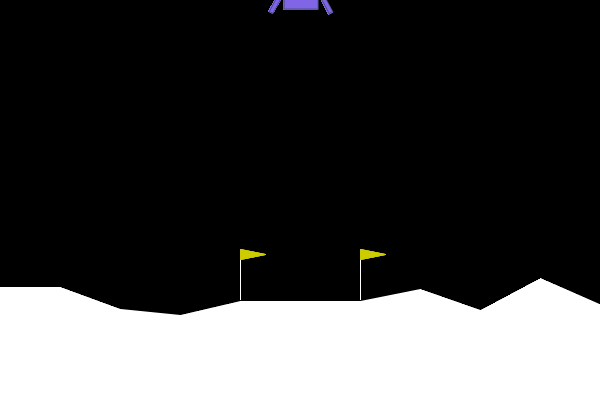

Dueling DQN:


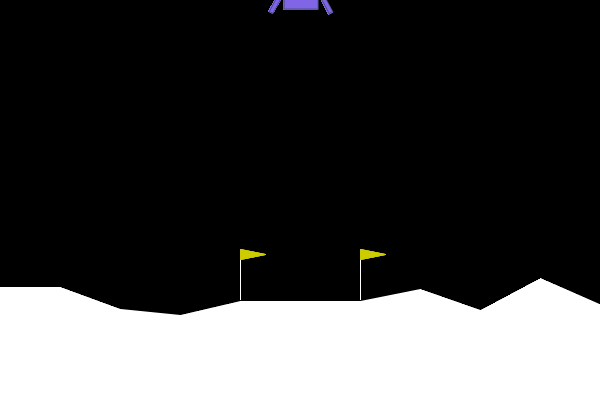

In [ ]:
def record_gif(env_id, q_net, filename, n_episodes=1, max_steps=1000, seed=100):
    env = gym.make(env_id, render_mode="rgb_array")
    frames = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        steps = 0
        while not done and steps < max_steps:
            frames.append(env.render())
            with torch.no_grad():
                obs_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
                action = int(q_net(obs_t).argmax(dim=1).item())
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            steps += 1
    env.close()
    imageio.mimsave(filename, frames, fps=30)
    return filename

dqn_gif = record_gif(ENV_ID, dqn_net, "dqn.gif")
dueling_gif = record_gif(ENV_ID, dueling_net, "dueling_dqn.gif")

print("DQN estándar:")
display(Image(filename=dqn_gif))
print("Dueling DQN:")
display(Image(filename=dueling_gif))

## Conclusiones

- La **arquitectura** es la única diferencia entre ambos agentes: mismo buffer, mismos hiperparámetros, misma semilla, mismo entorno.
- En entornos con varias acciones donde no todas importan igual en todo momento (como `LunarLander-v3`), Dueling DQN suele aprender **más rápido y de forma más estable**, porque $V(s)$ puede actualizarse con cada transición sin depender de cuál acción se tomó.
